<a href="https://colab.research.google.com/github/enslern/The-AI-engineer-course-2026-Complete-AI-bootcamp/blob/main/Categorisng_fake_news(case_study).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install vaderSentiment
!pip install gensim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 46.3 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = "#00bfbf"

In [3]:
data=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/resources/fake_news_data.csv")

In [4]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


<Axes: xlabel='fake_or_factual'>

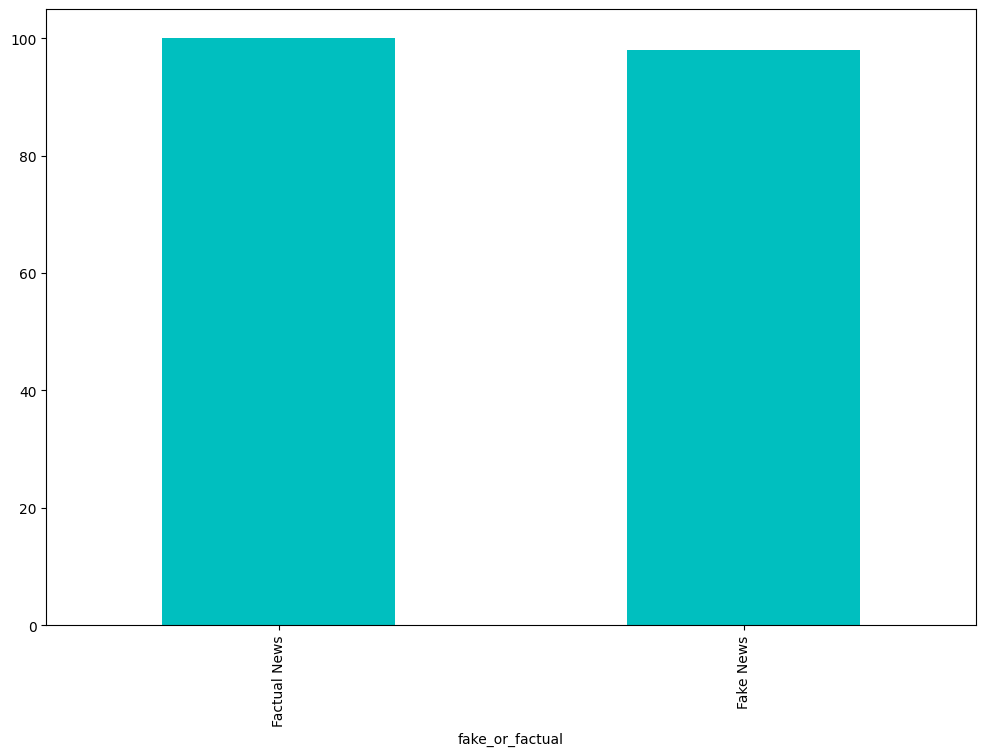

In [5]:
data["fake_or_factual"].value_counts().plot(kind="bar",color=default_plot_colour)

# **POS TAGGING**

In [6]:
nlp=spacy.load("en_core_web_sm")

In [7]:
fake_news=data[data["fake_or_factual"]=="Fake News"]
factual_news=data[data["fake_or_factual"]=="Factual News"]

In [8]:
fake_spacydocs=list(nlp.pipe(fake_news["text"]))
factual_spacydocs=list(nlp.pipe(factual_news["text"]))

In [9]:
def extract_tokens(doc:spacy.tokens.doc.Doc):
  return [(i.text,i.ent_type_,i.pos_) for i in doc]

In [10]:
fake_tagsdf=[]
columns=["token","ner_tag","pos_tag"]
for ix,doc in enumerate(fake_spacydocs):
  extracted_tags=extract_tokens(doc)
  tags=pd.DataFrame(extracted_tags)
  tags.columns=columns
  fake_tagsdf.append(tags)
fake_tagsdf=pd.concat(fake_tagsdf)

fact_tagdf=[]
for ix , doc in enumerate(factual_spacydocs):
  extracted_tags=extract_tokens(doc)
  tags=pd.DataFrame(extracted_tags)
  tags.columns=columns
  fact_tagdf.append(tags)
fact_tagdf=pd.concat(fact_tagdf)

In [11]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [12]:
pos_countfake=fake_tagsdf.groupby(["token","pos_tag"]).size().reset_index(name="counts").sort_values(by="counts",ascending=False)

In [13]:
pos_countfake.head()

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875


In [14]:
pos_countfact=fact_tagdf.groupby(["token","pos_tag"]).size().reset_index(name="counts").sort_values(by="counts",ascending=False)

In [15]:
pos_countfact.head()

,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789


In [16]:
pos_countfake.groupby(["pos_tag"])["token"].count().sort_values(ascending=False)

,token
pos_tag,
NOUN,2586
VERB,1817
PROPN,1672
ADJ,882
ADV,413
NUM,221
PRON,96
ADP,89
AUX,62


In [17]:
pos_countfact.groupby(["pos_tag"])["token"].count().sort_values(ascending=False)

,token
pos_tag,
NOUN,2179
VERB,1539
PROPN,1379
ADJ,747
ADV,263
NUM,205
PRON,79
ADP,70
AUX,43


In [18]:
pos_countfake[pos_countfake.pos_tag=="NOUN"]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
...,...,...,...
4877,idiocy,NOUN,1
4878,idiot,NOUN,1
2539,administrators,NOUN,1
4903,impeach,NOUN,1


In [19]:
pos_countfact[pos_countfact.pos_tag=="NOUN"]

,token,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
...,...,...,...
6595,worker,NOUN,1
3220,drop,NOUN,1
3203,dread,NOUN,1
3204,dreamers,NOUN,1


# **NAMED ENTITIES**

In [20]:
fake_tagsdf=[]
columns=["token","ner_tag","pos_tag"]
for ix,doc in enumerate(fake_spacydocs):
  extracted_tags=extract_tokens(doc)
  tags=pd.DataFrame(extracted_tags)
  tags.columns=columns
  fake_tagsdf.append(tags)
fake_tagsdf=pd.concat(fake_tagsdf)

fact_tagdf=[]
for ix , doc in enumerate(factual_spacydocs):
  extracted_tags=extract_tokens(doc)
  tags=pd.DataFrame(extracted_tags)
  tags.columns=columns
  fact_tagdf.append(tags)
fact_tagdf=pd.concat(fact_tagdf)

top_entities_fake=fake_tagsdf[fake_tagsdf["ner_tag"]!=""].groupby(["token","ner_tag"]).size().reset_index(name="counts").sort_values(by="counts",ascending=False)

In [21]:
top_entities_fact=fact_tagdf[fact_tagdf.ner_tag!=""].groupby(["token","ner_tag"]).size().reset_index(name="counts").sort_values(by="counts",ascending=False)

In [22]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'most common entities  in fake news')]

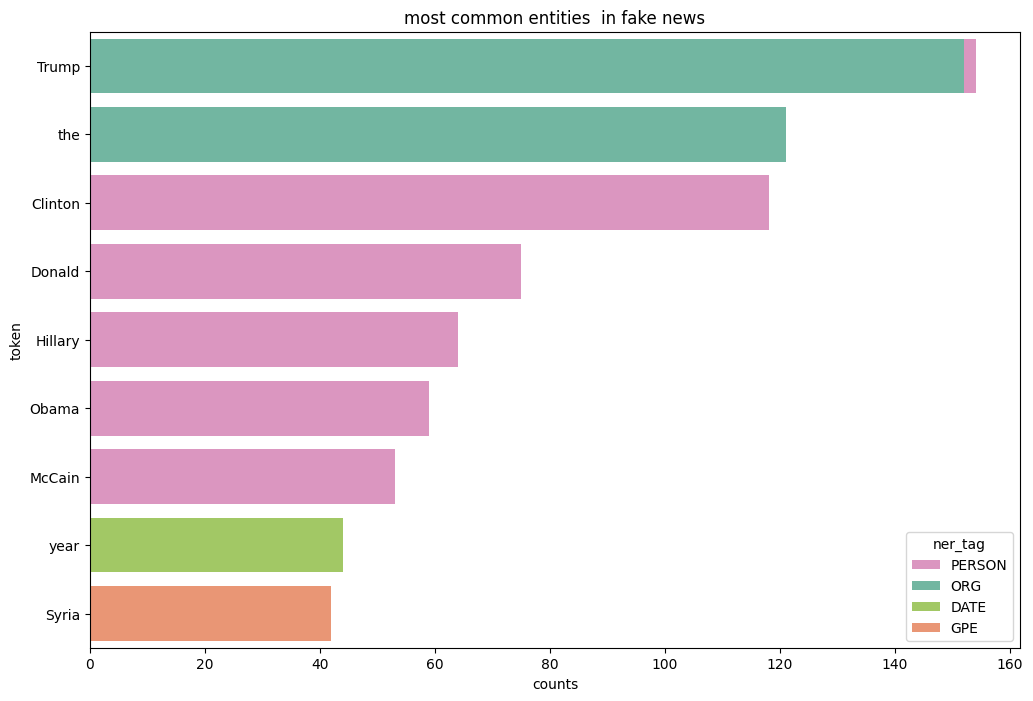

In [23]:
sns.barplot(
    x="counts",
    y="token",
    hue="ner_tag",
    palette=ner_palette,
    data=top_entities_fake[0:10],
    orient="h",
    dodge=False
).set(title="most common entities  in fake news")

[Text(0.5, 1.0, 'most common entities  in fake news')]

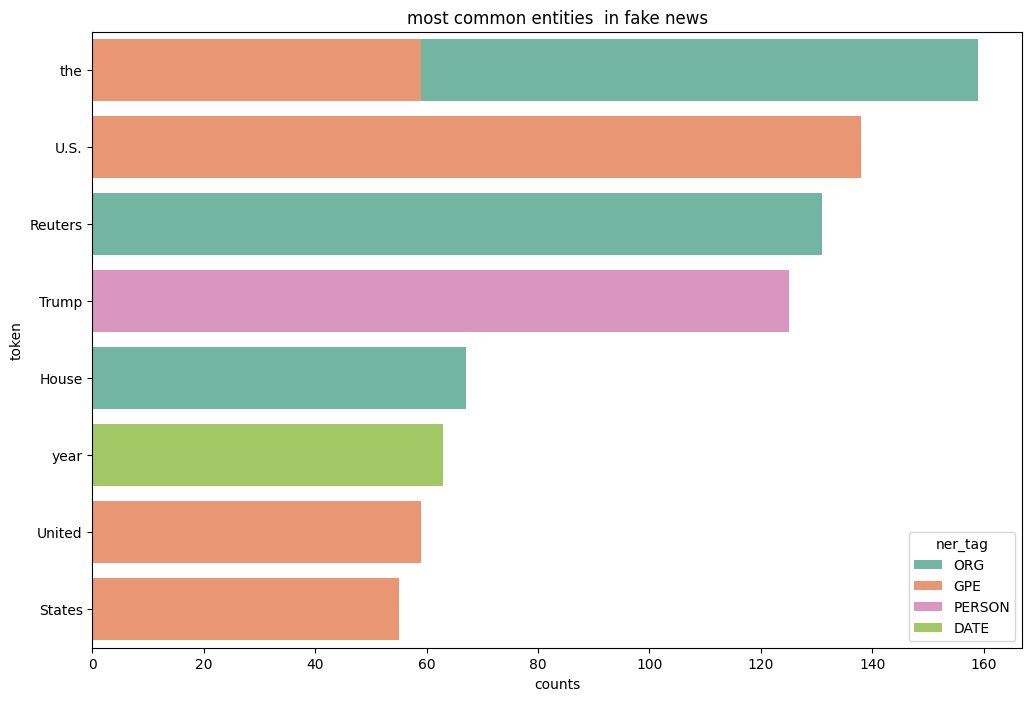

In [24]:
sns.barplot(
    x="counts",
    y="token",
    hue="ner_tag",
    palette=ner_palette,
    data=top_entities_fact[0:10],
    orient="h",
    dodge=False
).set(title="most common entities  in fake news")

# **TEXT PRE-PROCESSING**

In [25]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [26]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s*", "", x['text']), axis=1)

In [27]:
data["text_clean"]=data["text_clean"].str.lower()

In [28]:
data["text_clean"]=data["text_clean"].apply(lambda x: re.sub(r"[^\w\s]"," ",x))

In [29]:
en_stopwords=stopwords.words("english")
data["text_clean"]=data["text_clean"].apply(lambda x: " ".join([word for word in x.split() if word not in en_stopwords]))

In [30]:
import nltk
nltk.download('punkt_tab')
data["text_clean"]=data["text_clean"].apply(lambda x: word_tokenize(x) )

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [31]:
import nltk
nltk.download('wordnet')
lemmatizer=WordNetLemmatizer()
data["text_clean"]=data["text_clean"].apply(lambda x :[lemmatizer.lemmatize(word) for word in x])

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [32]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[year, old, oscar, winning, actress, described..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [38]:
tokens_clean=sum(data["text_clean"],[])
unigrams=(pd.Series(nltk.ngrams(tokens_clean,1))).value_counts().reset_index()[:10]

In [39]:
unigrams.head()

,index,count
0,"(said,)",573
1,"(trump,)",550
2,"(u,)",288
3,"(state,)",259
4,"(president,)",238


In [40]:
unigrams["token"]=unigrams["index"].apply(lambda x: x[0])

/tmp/ipykernel_2183/2680314542.py:1: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = "count",


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

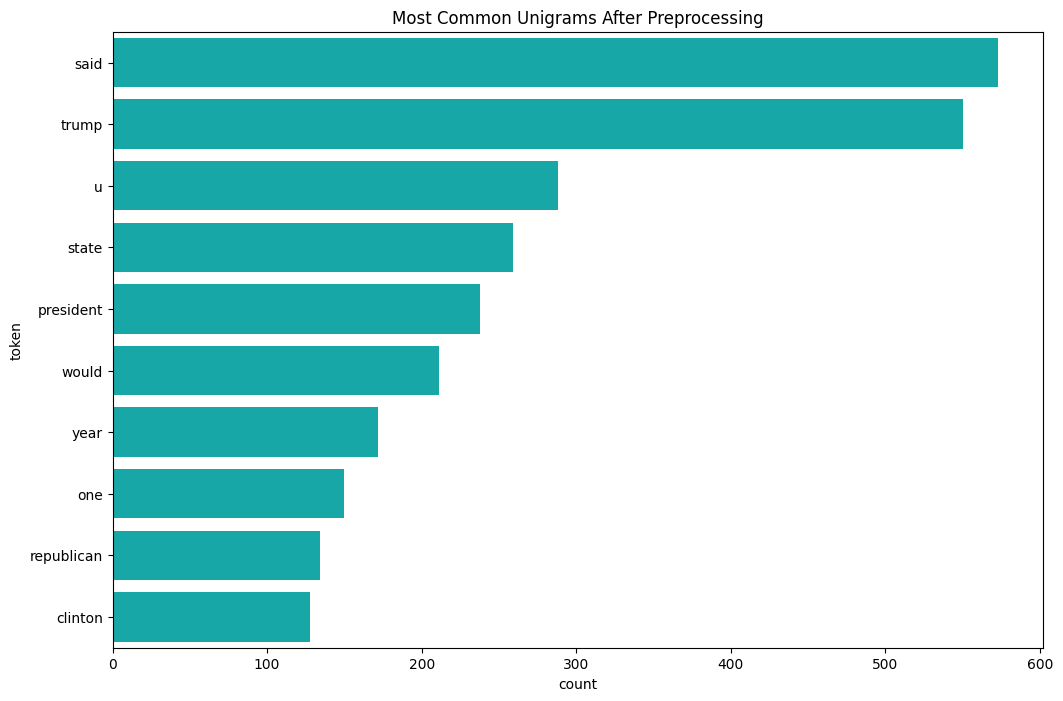

In [41]:
sns.barplot(x = "count",
            y = "token",
            data=unigrams,
            orient = 'h',
            palette=[default_plot_colour],
            hue = "token", legend = False)\
.set(title='Most Common Unigrams After Preprocessing')

# **SENTIMENT ANALYSIS**

In [43]:
vadersentiment=SentimentIntensityAnalyzer()

In [48]:
data["vader_sentiment_score"]=data["text"].apply(lambda x: vadersentiment.polarity_scores(x)["compound"])

In [49]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_label,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[year, old, oscar, winning, actress, described...",-0.3660,-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,0.8590


In [51]:
bins=[-1,-0.1,0.1,1]
names=["negative","neutral","positive"]

In [53]:
data["vader_sentiment_label"]=pd.cut(data["vader_sentiment_score"],bins,labels=names)

<Axes: xlabel='vader_sentiment_label'>

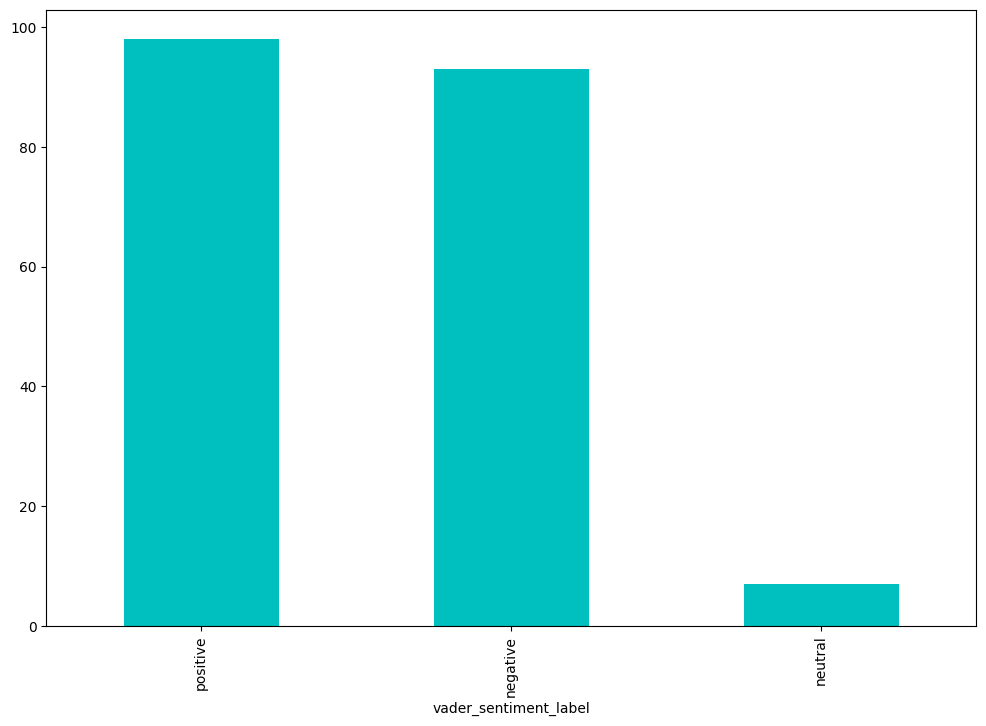

In [54]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

/tmp/ipykernel_2183/56751153.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

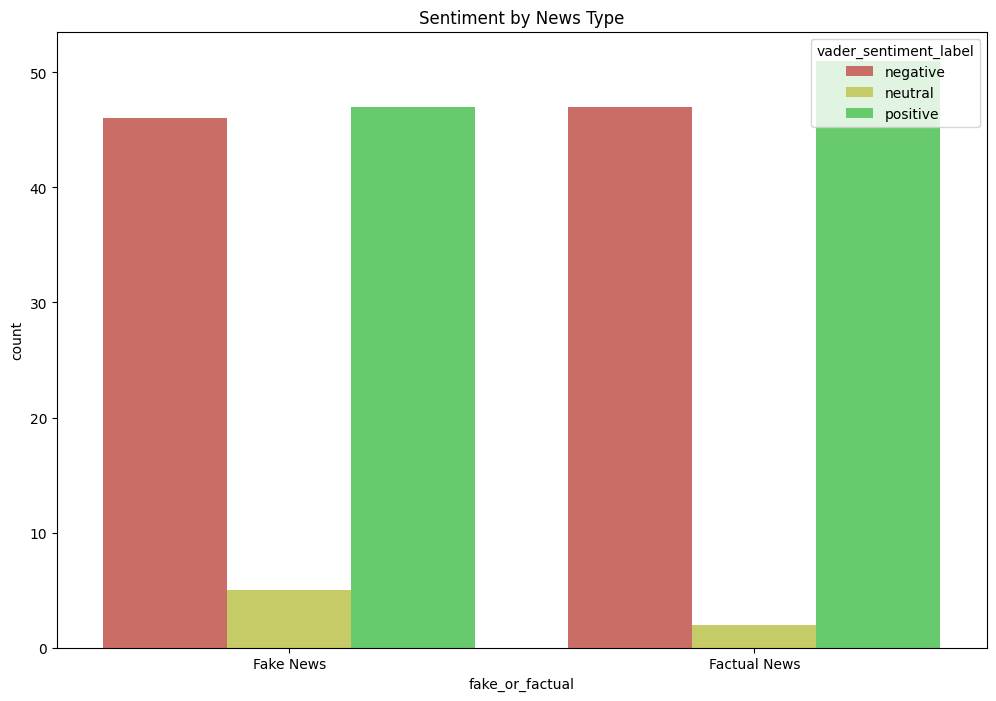

In [55]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    palette = sns.color_palette("hls"),
    data = data
) \
.set(title='Sentiment by News Type')


# **LDA**

In [56]:
fake_news_text=data[data["fake_or_factual"]=="Fake News"]["text_clean"].reset_index(drop=True)

In [58]:
dictionary_fake=corpora.Dictionary(fake_news_text)